# Task 5_ Trích xuất đặc trưng HOG cho ROI

- **Mục tiêu:** Biến mỗi ảnh ROI (đã crop + resize 64×64 ở Task 4) thành 1 vector đặc trưng số bằng HOG làm đầu vào cho SVM ở Task 6.

- Lý do chọn HOG là vì HOG mô tả hình dạng vật thể bằng phân bố hướng cạnh (gradient), phù hợp với biển báo vì hình dạng hình học (tam giác/tròn/vuông) và ký hiệu bên trong tạo ra các cạnh đặc trưng, ổn định hơn màu sắc (vốn đã dùng ở Task 2) trước biến động ánh sáng/thời tiết.

- **Input / Output:**
    - Input: Ảnh ROI đã crop + resize 64×64 (Task 4) và `roi_manifest.json` (nhãn lớp + train/val split tương ứng).
    - Output: Ma trận đặc trưng `X_train`/`X_val` (HOG) và nhãn `y_train`/`y_val` tương ứng, lưu dạng `.npy`, dùng làm input trực tiếp cho Task 7 (SVM).

- **Quy trình thực hiện:**
  1. Nạp `roi_manifest.json` (nhãn + split) đã gán ở Task 4, thống kê phân bố lớp.
  2. Trực quan hoá đặc trưng HOG trên 1 mẫu positive (biển báo) và 1 mẫu negative (nền/nhiễu).
  3. Khảo sát tham số `orientations` (6/9/12), cố định `pixels_per_cell=(8,8)`.
  4. Khảo sát tham số `pixels_per_cell` ((4,4)/(8,8)/(16,16)), cố định `orientations=9`.
  5. Chốt bộ tham số HOG + thành phần đặc trưng (HOG-only, đã thử ghép thêm color histogram và loại bỏ vì không cải thiện F1-macro).
  6. Trích xuất đặc trưng cho toàn bộ tập train/val (tách theo `split` đã có sẵn từ Task 5, không gọi lại `train_test_split`), lưu `.npy` + cập nhật `config.yaml`.

# 1. Import thư viện

In [17]:
import sys
import json
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path
from collections import Counter         

# 2. Cài đặt đường dẫn & nạp cấu hình

In [18]:
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_config
from src.utils import show_images
from src.feature_extraction import extract_hog_features   # (feat_vector, hog_image) = extract_hog_features(img, **params)

CFG, PROJECT_ROOT, CONFIG_PATH = load_config(PROJECT_ROOT)

# Input: ROI ảnh + manifest (nhãn + split) từ Task 4
ROI_IMG_DIR  = PROJECT_ROOT / "data" / "processed" / "task4_roi" / "images"
ROI_META_DIR = PROJECT_ROOT / "data" / "processed" / "task4_roi" / "meta"

# Output: đặc trưng HOG của Task 5
FEATURE_DIR  = PROJECT_ROOT / "data" / "processed" / "task5_hog"
FEATURE_DIR.mkdir(parents=True, exist_ok=True)


## 3. Nạp danh sách ROI đã gán nhãn (roi_manifest.json từ Task 4)

In [19]:
with open(ROI_META_DIR / "roi_manifest.json", "r", encoding="utf-8") as f:
    manifest = json.load(f)  

label_counts = Counter(r["label"] for r in manifest)   # số ROI theo từng class (-1 = nền/nhiễu)
split_counts = Counter(r["split"] for r in manifest)   # số ROI theo train/test

print(f"Tổng số ROI trong manifest: {len(manifest)}")
print(f"Số lượng class (bao gồm -1 = nền/nhiễu): {len(label_counts)}")
print(f"Phân bố theo class:")
for cls, count in sorted(label_counts.items()):
    tag = "Nền/nhiễu" if cls == -1 else f"Class {cls}"
    print(f"  {tag:<15}: {count}")
print(f"Phân bố split: {split_counts}")


Tổng số ROI trong manifest: 19359
Số lượng class (bao gồm -1 = nền/nhiễu): 53
Phân bố theo class:
  Nền/nhiễu      : 14626
  Class 0        : 219
  Class 1        : 16
  Class 2        : 143
  Class 3        : 155
  Class 4        : 24
  Class 5        : 169
  Class 6        : 143
  Class 7        : 181
  Class 8        : 187
  Class 9        : 25
  Class 10       : 517
  Class 11       : 20
  Class 12       : 157
  Class 13       : 211
  Class 14       : 56
  Class 15       : 11
  Class 16       : 36
  Class 17       : 77
  Class 18       : 95
  Class 19       : 28
  Class 20       : 26
  Class 21       : 9
  Class 22       : 50
  Class 23       : 246
  Class 24       : 46
  Class 25       : 16
  Class 26       : 47
  Class 27       : 26
  Class 28       : 19
  Class 29       : 17
  Class 30       : 104
  Class 31       : 20
  Class 32       : 124
  Class 33       : 17
  Class 34       : 77
  Class 35       : 66
  Class 36       : 60
  Class 37       : 36
  Class 38       : 121
  Clas

## 4. Trực quan hóa đặc trưng HOG trên 1 mẫu Positive và 1 mẫu Negative

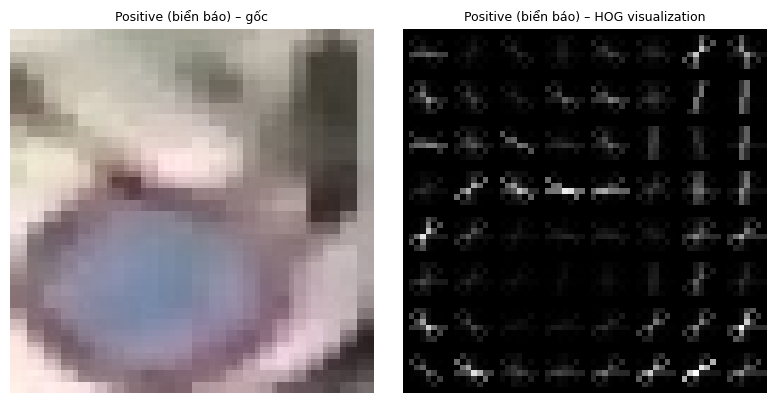

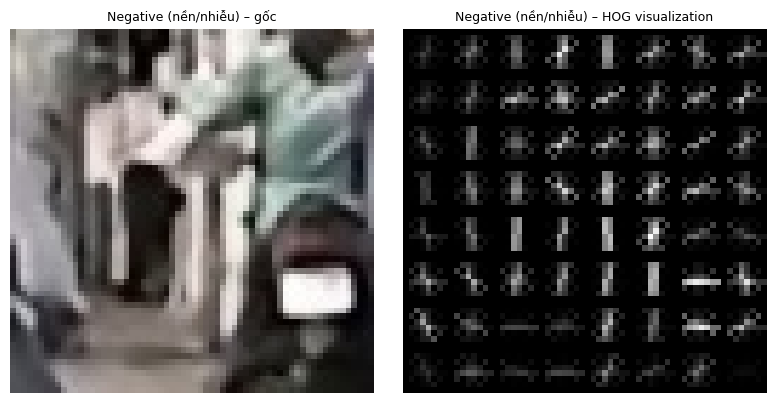

In [20]:
sample_pos = next(r for r in manifest if r["label"] != -1)   # lấy 1 ROI biển báo thật bất kỳ
sample_neg = next(r for r in manifest if r["label"] == -1)    # lấy 1 ROI nền/nhiễu bất kỳ

for r, tag in [(sample_pos, "Positive (biển báo)"), (sample_neg, "Negative (nền/nhiễu)")]:
    img = cv2.imread(str(ROI_IMG_DIR / r["roi_file"]))
    _, hog_img = extract_hog_features(img)   # dùng tham số mặc định của hàm chỉ để minh họa trực quan

    # Chuẩn hóa hog_img về [0, 255] và chuyển 3 kênh để show_images() (vốn convert BGR->RGB) hiển thị đúng
    hog_vis = cv2.cvtColor((hog_img / hog_img.max() * 255).astype("uint8"), cv2.COLOR_GRAY2BGR)
    show_images([img, hog_vis], [f"{tag} – gốc", f"{tag} – HOG visualization"], figsize=(8, 4))


## 5. Khảo sát định tính tham số HOG

In [21]:
random.seed(42)
sample_items = random.sample([r for r in manifest if r["label"] != -1], 3)  # lấy ROI biển báo thật, dễ nhìn hơn nền
sample_imgs  = [cv2.imread(str(ROI_IMG_DIR / r["roi_file"])) for r in sample_items]

## 5.1. Khảo sát orientations (cố định pixels_per_cell=(8,8), cells_per_block=(2,2))

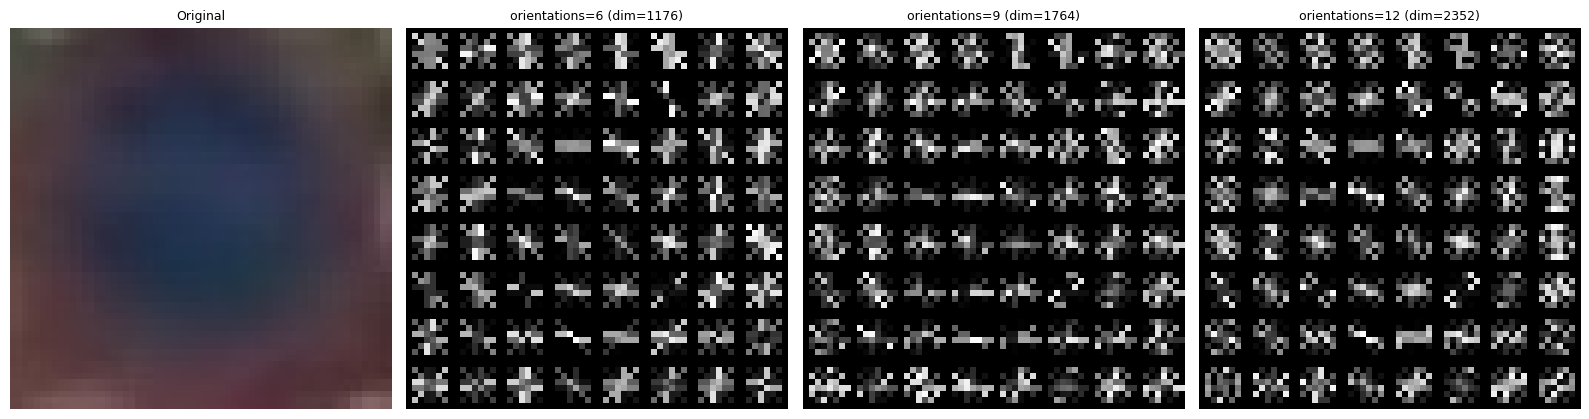

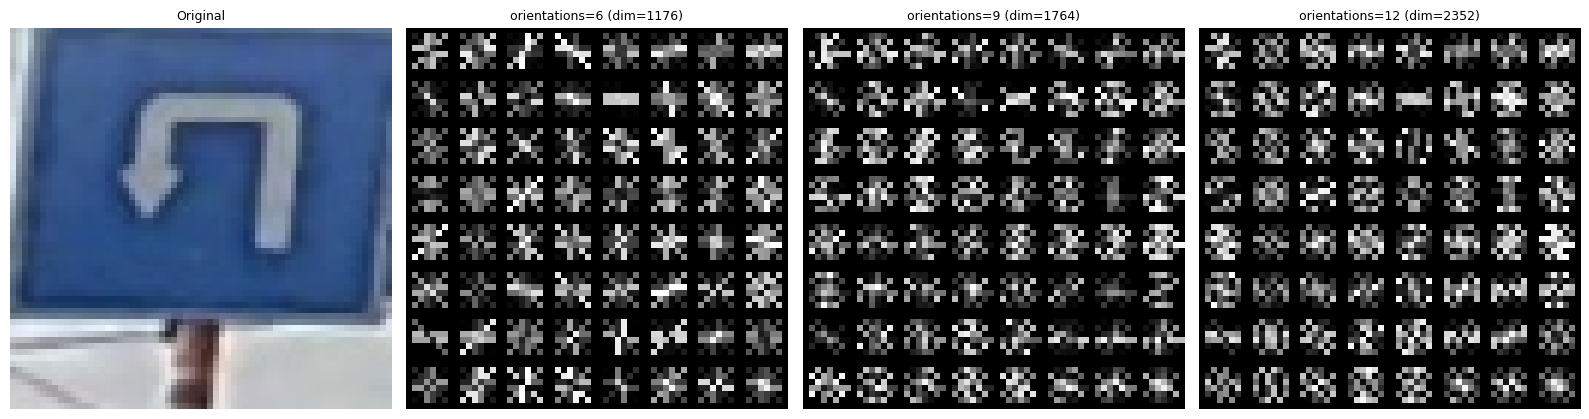

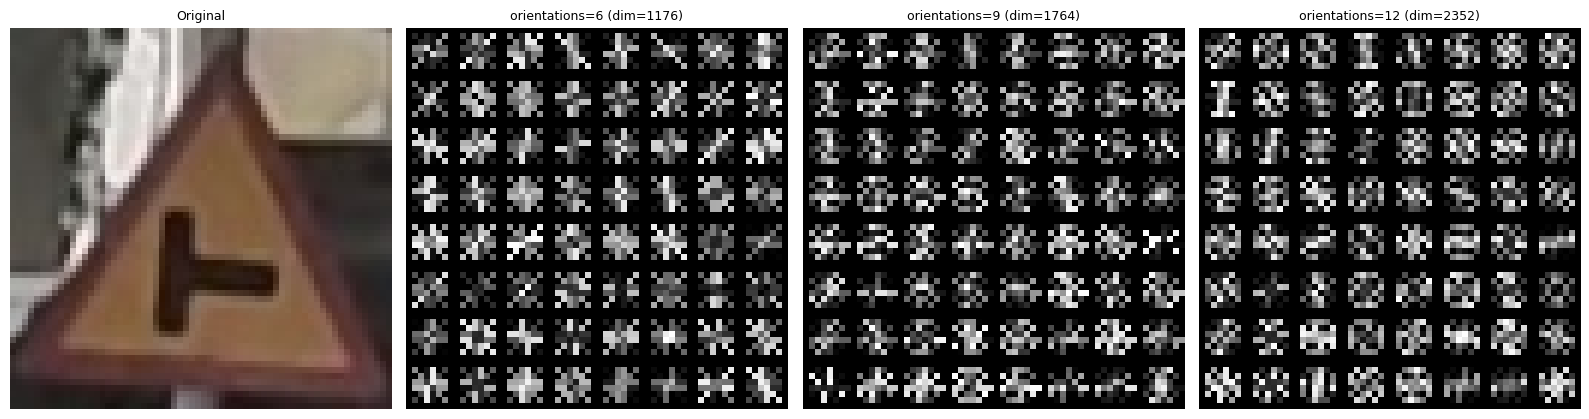

In [22]:
ORIENTATIONS_SWEEP = [6, 9, 12]

for img in sample_imgs:
    imgs_to_show, titles = [img], ["Original"]
    for ori in ORIENTATIONS_SWEEP:
        feat, hog_img = extract_hog_features(
            img, orientations=ori, pixels_per_cell=(8, 8), cells_per_block=(2, 2)
        )
        imgs_to_show.append(cv2.cvtColor((hog_img * 255).astype("uint8"), cv2.COLOR_GRAY2BGR))
        titles.append(f"orientations={ori} (dim={feat.shape[0]})")
    show_images(imgs_to_show, titles, figsize=(16, 5))

**Nhận xét:**
- Cả 3 giá trị orientations (6, 9, 12) đều dùng cùng pixels_per_cell=(8,8) nên **cấu trúc không gian** của ảnh HOG giống hệt nhau (cùng số ô, cùng vị trí), khác biệt chỉ nằm ở **độ mịn của hướng gradient** trong mỗi ô.
  - `orientations=6` cho các pattern trong từng ô đơn giản, ít nét gãy khúc hơn.
  -  `orientations=9` (mỗi bin ~20°) bắt đầu thấy nét chi tiết hơn ở vài ô, đặc biệt dọc theo viền cong của vòng tròn đỏ (ảnh 2, 3). 
  - `orientations=12` (mỗi bin 15°) cho pattern dày đặc/rối hơn nhưng nhìn tổng thể **không cho thấy chi tiết hình dạng mới đáng kể** so với 9
- Đánh đổi chiều đặc trưng khá rõ: 6->9 tăng ~50% (1176->1764), 9->12 tăng thêm ~33% (1764->2352) trong khi lợi ích quan sát được từ 9 lên 12 là không tương xứng với chi phí tăng thêm.

**Kết luận:** chọn `orientations=9` đã đủ mịn để phân biệt hướng cạnh chính (viền tròn, nét chéo, mũi tên) của biển báo, tăng lên 12 không mang lại cải thiện rõ rệt mà tốn thêm ~33% chiều đặc trưng.

## 5.2. Khảo sát pixels_per_cell (cố định orientations=9, cells_per_block=(2,2))

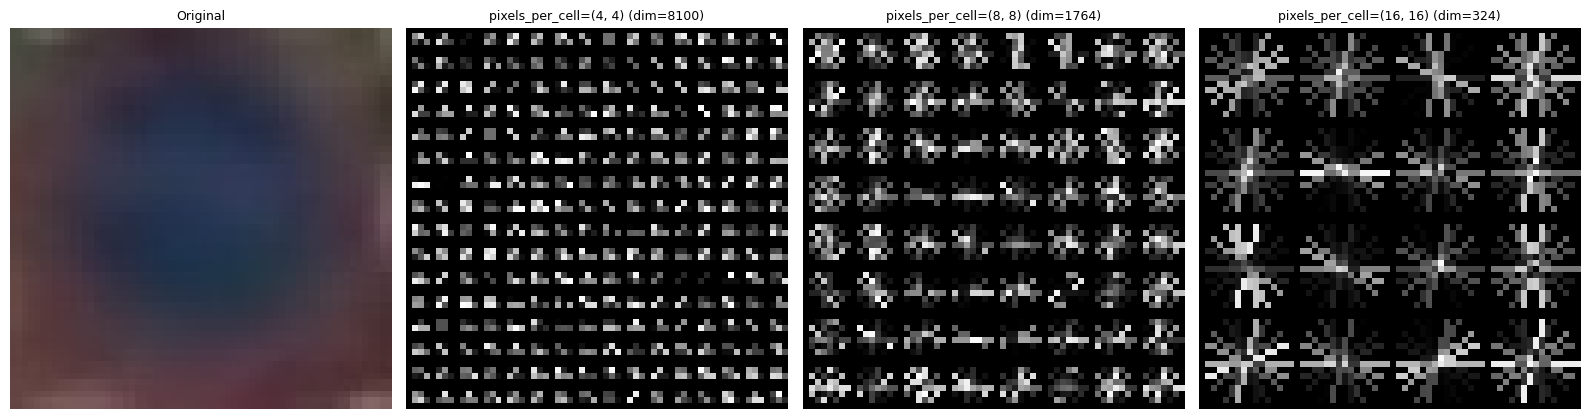

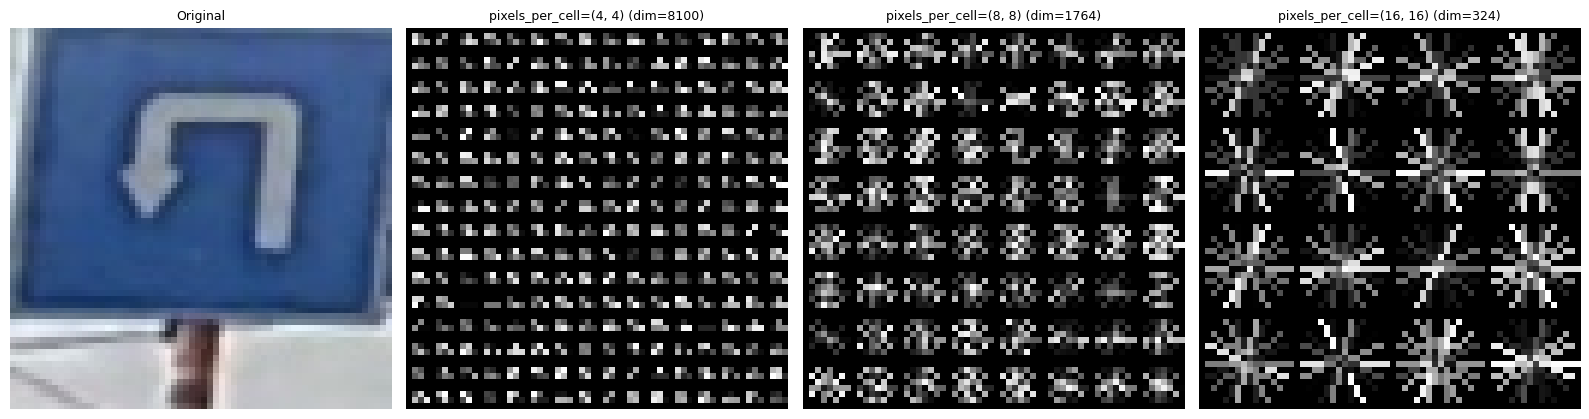

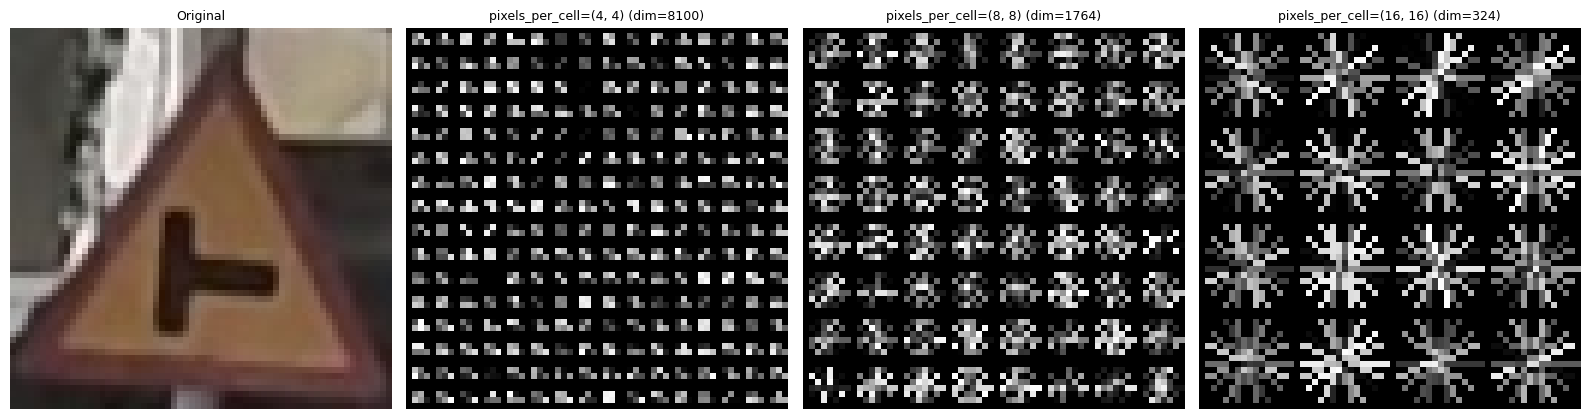

In [23]:
CELL_SIZE_SWEEP = [(4, 4), (8, 8), (16, 16)]

for img in sample_imgs:
    imgs_to_show, titles = [img], ["Original"]
    for cell in CELL_SIZE_SWEEP:
        feat, hog_img = extract_hog_features(
            img, orientations=9, pixels_per_cell=cell, cells_per_block=(2, 2)
        )
        imgs_to_show.append(cv2.cvtColor((hog_img * 255).astype("uint8"), cv2.COLOR_GRAY2BGR))
        titles.append(f"pixels_per_cell={cell} (dim={feat.shape[0]})")
    show_images(imgs_to_show, titles, figsize=(16, 5))

**Nhận xét:**
- pixels_per_cell=(4,4): Lưới ô rất dày (nhiều ô nhỏ), mỗi ô chỉ chứa vài pixel nên gradient gần như chỉ phản ánh **nhiễu cục bộ/texture mịn** thay vì cấu trúc hình dạng biển báo, nhìn 3 ảnh đều thấy pattern rời rạc, không có nét nào liên kết thành đường viền/hình dạng rõ ràng. Đổi lại, chiều đặc trưng tăng vọt lên 8100 (gấp ~4.6 lần so với (8,8)).
- pixels_per_cell=(8,8): Bắt đầu thấy nét gradient nối liền thành cấu trúc, dọc viền tròn đỏ (ảnh 2, 3) và vùng chuyển màu của xe/vật thể (ảnh 1) đã lên hình dạng nhận biết được.
- pixels_per_cell=(16,16): Mỗi ô gộp vùng quá lớn, chỉ còn 4×4 ô toàn ảnh, mỗi ô là 1 pattern hình sao lan toả (starburst) do gộp gradient từ nhiều hướng khác nhau trong cùng 1 ô, cấu trúc hình dạng cụ thể của biển báo (viền tròn, nét chéo, mũi tên) gần như biến mất, khó phân biệt biển này với biển khác chỉ dựa vào đặc trưng này.

**Kết luận:** chọn `pixels_per_cell=(8,8)` vì đây là điểm cân bằng duy nhất giữ được cấu trúc hình dạng biển báo rõ ràng. Đủ nhỏ để không hoà tan chi tiết như (16,16), nhưng đủ lớn để không vỡ vụn thành nhiễu cục bộ như (4,4), đồng thời chiều đặc trưng (1764) hợp lý hơn nhiều so với (4,4) (8100).

**Tổng hợp tham số HOG**
- `orientations`= **9**: Đủ mịn hướng cạnh; 12 tăng dim ~33% mà ít lợi quan sát 
- `pixels_per_cell` = **(8,8)**: Cân bằng cấu trúc hình dạng vs nhiễu; (4,4) vỡ nát, (16,16) mất chi tiết 
- `cells_per_block`= **(2,2)**: Chuẩn HOG (Dalal–Triggs), chuẩn hóa block ổn định 



In [24]:
SELECTED_HOG_PARAMS = dict(
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
)
print("SELECTED_HOG_PARAMS =", SELECTED_HOG_PARAMS)


SELECTED_HOG_PARAMS = {'orientations': 9, 'pixels_per_cell': (8, 8), 'cells_per_block': (2, 2)}


In [25]:
SELECTED_FEATURE_COMPOSITION = "HOG only"
print(f"Composition: {SELECTED_FEATURE_COMPOSITION}")

Composition: HOG only


## 6. Trích xuất đặc trưng HOG cho toàn bộ Train/Val

Tách `train_items`/`val_items` bằng đúng field `split` đã gán ở Task 5 (theo ảnh gốc), không gọi lại `train_test_split` ở đây, để tránh bị data leakage mà Task 5 đã đảm bảo. 
Dùng `SELECTED_HOG_PARAMS` vừa chọn ở Mục 5, không dùng giá trị mặc định

In [ ]:
train_items = [r for r in manifest if r["split"] == "train"]
val_items   = [r for r in manifest if r["split"] == "val"]
test_items  = [r for r in manifest if r["split"] == "test"]

def build_feature_matrix(items):
    # HOG-only (đã bỏ color histogram — xem khảo sát Mục 5: ghép color không cải thiện F1-macro)
    X, y = [], []
    for r in items:
        img = cv2.imread(str(ROI_IMG_DIR / r["roi_file"]))
        if img is None:
            continue
        hog_feat, _ = extract_hog_features(img, **SELECTED_HOG_PARAMS)
        X.append(hog_feat)
        y.append(r["label"])
    return np.array(X), np.array(y)

print("Đang trích xuất HOG cho tập train...")
X_train, y_train = build_feature_matrix(train_items)
print("Đang trích xuất HOG cho tập val...")
X_val, y_val = build_feature_matrix(val_items)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print("Đang trích xuất HOG cho tập test khóa...")
X_test, y_test = build_feature_matrix(test_items)
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

In [ ]:
np.save(FEATURE_DIR / "X_train.npy", X_train)
np.save(FEATURE_DIR / "y_train.npy", y_train)
np.save(FEATURE_DIR / "X_val.npy", X_val)
np.save(FEATURE_DIR / "y_val.npy", y_val)
np.save(FEATURE_DIR / "X_test.npy", X_test)
np.save(FEATURE_DIR / "y_test.npy", y_test)

from src.data_loader import save_config

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

cfg.setdefault("task5", {})
cfg["task5"]["hog_params"] = {
    "orientations": SELECTED_HOG_PARAMS["orientations"],
    "pixels_per_cell": list(SELECTED_HOG_PARAMS["pixels_per_cell"]),
    "cells_per_block": list(SELECTED_HOG_PARAMS["cells_per_block"]),
}

cfg["task5"].pop("color_hist_bins", None)
cfg["task5"]["n_features"] = int(X_train.shape[1])
cfg["task5"]["feature_composition"] = f"HOG({int(X_train.shape[1])}) only"

save_config(cfg, CONFIG_PATH)

print(f"Đã lưu đặc trưng vào: {FEATURE_DIR}")
print(f"Đã cập nhật config.yaml — task5:")
print(f"  hog_params={cfg['task5']['hog_params']}")
print(f"  n_features={cfg['task5']['n_features']} | {cfg['task5']['feature_composition']}")
